In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

import warnings

2026-05-19 17:04:26.317737: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779210266.581311      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779210266.659593      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779210267.436611      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779210267.436681      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779210267.436685      16 computation_placer.cc:177] computation placer alr

In [3]:
## -- Global Settings --

# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

## -- Set Global Seed --
class CFG():
    SEED   = 42
    GREEN  = '\033[32m'
    YELLOW = '\033[33m'
    RESET  = '\033[0m'

tf.keras.utils.set_random_seed(CFG.SEED)

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    "axes.edgecolor":   '#444466',
    "axes.labelcolor":  '#e0e0ff',
    "text.color":       'lightblue',
    "xtick.color":      '#e0e0ff',
    "ytick.color":      '#e0e0ff',
    "grid.color":       '#2a2a4a',
    "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

print(f"CLASSIC {CFG.GREEN} GREEN {CFG.RESET} {CFG.YELLOW} YELLOW {CFG.RESET}")

CLASSIC  GREEN   YELLOW 


In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e5/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
    test = pd.read_csv(PATH+"test.csv").drop(columns=['id'])
    ORIG_PATH = '/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/'
    orig = pd.read_csv(ORIG_PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e5 | F1 Pits Stop/_f1_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop(columns=['id'])
    test = pd.read_csv(PATH+'test.csv').drop(columns=['id'])
    orig = pd.read_csv(PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]

CATS = [c for c in test.columns if test[c].dtype in ['str', 'object', 'category']]
NUMS = [c for c in test.columns if c not in CATS+[TARGET]]
BASE = NUMS + CATS

orig = orig[train.columns]

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(NUMS)}")
print(f"Total Cats: {len(CATS)}")
print(f"Total Base: {len(BASE)}")

train[TARGET] = train[TARGET].astype('int8')
orig[TARGET]  = orig[TARGET].astype('int8')

Train shape: (439140, 15)
Test shape: (188165, 14)
Original shape: (101371, 15)

Total Nums: 11
Total Cats: 3
Total Base: 14


In [5]:
display(train.head())
train.info()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [6]:
train[NUMS].describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000


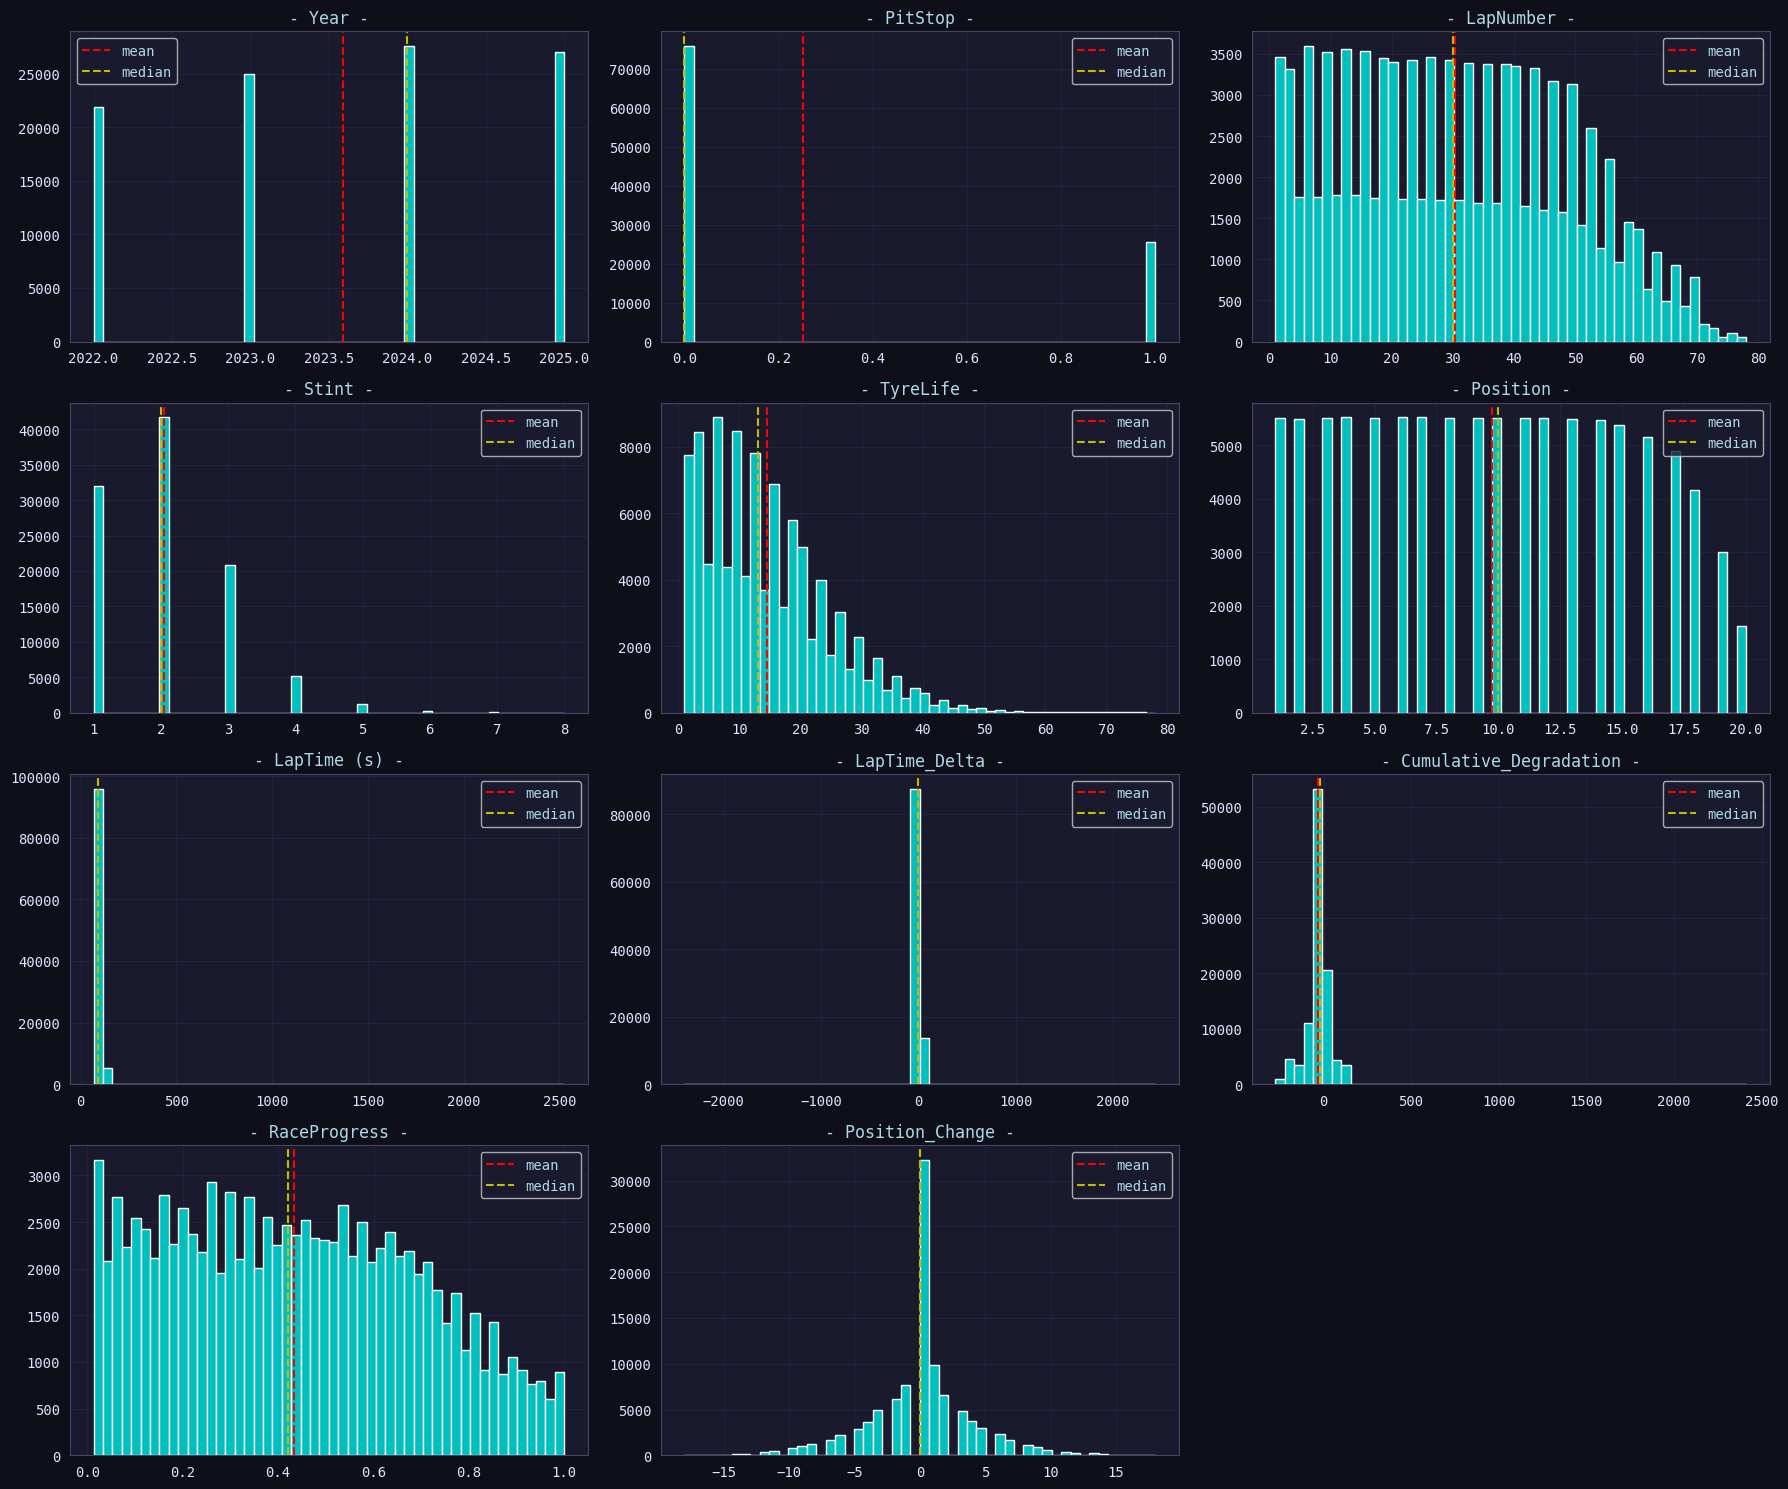

In [7]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [8]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Driver,Compound,Race
Train,4,2,78,8,78,20,37719,57532,142701,1898,37,887,5,26
Original,4,2,78,8,78,20,40779,54084,81360,1437,37,31,5,28
Test,4,2,77,8,77,20,30286,40673,86823,1556,37,801,5,26


In [9]:
n_unique = train[BASE].nunique().sort_values()
n_unique

PitStop                        2
Year                           4
Compound                       5
Stint                          8
Position                      20
Race                          26
Position_Change               37
LapNumber                     78
TyreLife                      78
Driver                       887
RaceProgress                1898
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
dtype: int64

# FEATURE ENGINEERING

In [10]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [11]:
# _extract_cols = ['Cumulative_Degradation', 'LapTime (s)'] # , 'LapTime_Delta'

# print(f"\nRounding... ", end='')
# for col in _extract_cols:
#     for r in range(-2, 3):
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')

#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in range(-3, 4):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [12]:
# print(f"\nRounding... ", end='')
# for col in ['LapTime (s)']:
#     for r in [-2, -1, 0, 1, 2]:
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in [0, 1, 2, 3, 4, 5, 6]:
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [10]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [5]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [13]:
# train = train.drop(columns=DROP_COLS)
# test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)

# print(f"Features dropped: {DROP_COLS}")

# train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

In [14]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [15]:
## -- Flag 'Year' == 2023 --
for df in [train, test, orig]:
    df['is_2023'] = (df['Year'] == 2023).astype('int8')

print('Flag Year:', 'is_2023')

Flag Year: is_2023


In [16]:
## -- Frequency encoding --
freq_cols = []

print(f"\nCreating frequencies... ", end='')
for col in CATS + ['LapNumber', 'RaceProgress']: # 'Position_Change'
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    n = f'{col}_freq'
    print(n+', ', end='')
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).fillna(0).astype('float32')
    freq_cols.append(n)

print(f"\n✓ Total frequency features: {len(freq_cols)}")


Creating frequencies... Driver_freq, Compound_freq, Race_freq, LapNumber_freq, RaceProgress_freq, 
✓ Total frequency features: 5


In [17]:
INTER = []
top_cols = ['Year', 'Compound', 'Stint', 'Race', 'PitStop'] 
low_cols = ['Position', 'Position_Change', 'LapNumber', 'TyreLife']

for c1, c2 in tqdm(list(itertools.combinations(top_cols, 2)), desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")

Pairwise:   0%|          | 0/10 [00:00<?, ?it/s]

Total Interaction Features: 10


In [18]:
# def FE(df1):
#     """
#     Comprehensive feature engineering for F1 Pit Stop prediction.
#     Focuses on: 
#     1. Fuel-corrected LapTimes
#     2. Stint-relative degradation
#     3. Track-specific strategic windows
#     """
#     df = df1.copy()
#     print('Feature engineering... ', end='')
#     # Sort for temporal consistency
#     df = df.sort_values(by=['Year', 'Race', 'Driver', 'LapNumber'])
    
#     # --- 1. LAPTIME TRANSFORMATION & FUEL CORRECTION ---
#     # F1 cars gain ~0.035s per lap due to fuel burn. 
#     # This 'normalizes' LapTime across the race duration.
#     df['Fuel_Corrected_LapTime'] = df['LapTime (s)'] + (df['LapNumber'] * 0.035)
    
#     # Group by stint for relative performance
#     stint_group = df.groupby(['Year', 'Race', 'Driver', 'Stint'])
    
#     # Relative pace: How much have we slowed since the start of THIS stint?
#     df['Stint_Min_LapTime'] = stint_group['LapTime (s)'].transform('min')
#     df['Pace_Loss_Stint'] = df['LapTime (s)'] - df['Stint_Min_LapTime']
    
#     # Rolling Volatility: High variance often precedes a pit (tire instability)
#     df['LapTime_Volatility_3L'] = df.groupby(['Year', 'Race', 'Driver'])['LapTime (s)'].transform(
#         lambda x: x.rolling(window=3, min_periods=1).std()
#     )
#     df['LapTime_Volatility_3L'] = df['LapTime_Volatility_3L'].fillna(0)

#     # --- 2. TIRE DEGRADATION DYNAMICS ---
#     # Calculate the 'acceleration' of wear (the second derivative)
#     df['Degradation_Rate'] = df.groupby(['Year', 'Race', 'Driver'])['Cumulative_Degradation'].diff()
#     df['Degradation_Acc'] = df.groupby(['Year', 'Race', 'Driver'])['Degradation_Rate'].diff()
#     df['Degradation_Rate'] = df['Degradation_Rate'].fillna(0)
#     df['Degradation_Acc'] = df['Degradation_Acc'].fillna(0)

#     # Compound Logic: Normalizing life based on typical compound limits
#     compound_max = {'SOFT': 18, 'MEDIUM': 32, 'HARD': 48}
#     df['Tyre_Life_Pct'] = df.apply(
#         lambda x: x['TyreLife'] / compound_max.get(x['Compound'], 30), axis=1
#     )

#     # --- 3. STRATEGIC WINDOWS (Target/Mean Encoding) ---
#     # Binning LapNumbers to find the 'High Probability' windows per race
#     # df['Lap_Bin'] = pd.cut(df['LapNumber'], bins=10, labels=False)
    
#     # Historical probability of pitting in this specific window at this specific track
#     # Note: In a real CV, this should be done within the fold to avoid leakage
#     # df['Race_Window_Prob'] = df.groupby(['Race', 'Lap_Bin'])['PitNextLap'].transform('mean')
    
#     # Compound-Stint interaction: Captures if it's a 'common' stop time
#     # df['Compound_Stint_Prob'] = df.groupby(['Compound', 'Stint'])['PitNextLap'].transform('mean')

#     # --- 4. POSITION & CONTEXT ---
#     # Net position change over last 3 laps (Pressure metric)
#     df['Recent_Pos_Change'] = df.groupby(['Year', 'Race', 'Driver'])['Position_Change'].transform(
#         lambda x: x.rolling(window=3, min_periods=1).sum()
#     )
    
#     # --- 5. CLEANUP FOR MODELS ---
#     # Fill temporal gaps with neutral values
    
#     # # Drop redundancy: 0.98 correlation between LapNumber and RaceProgress
#     # # RaceProgress is usually better for GBDTs/NNs as it's already 0-1 scaled.
#     # if 'LapNumber' in df.columns:
#     #     df_final = df.drop(columns=['LapNumber'])
#     # else:
#     #     df_final = df

#     print('Complete!')

#     return df

In [19]:
# train = FE(train)
# test  = FE(test)
# orig  = FE(orig)

In [20]:
## -- Arithmetic interactions --
for df in [train, test, orig]:
    df['_LapNumber_/_RaceProgress'] = (df['LapNumber'] / (df['RaceProgress'] + 1e-6)).astype('float32')
    df['_TyreLife_/_LapNumber'] = (df['TyreLife'] / df['LapNumber'].clip(lower=1)).astype('float32')
    df['_LapTime (s)_*_Cumulative_Degradation'] = (df['LapTime (s)'] * df['Cumulative_Degradation']).astype('float32')
    df['_LapTime (s)_*_Cumulative_Degradation_abs'] = (df['LapTime (s)'] * df['Cumulative_Degradation'].abs()).astype('float32')
    df['_LapTime (s)_/_Cumulative_Degradation_abs'] = (df['LapTime (s)'] / (df['Cumulative_Degradation'].abs() + 1e-6)).astype('float32')

arithmetic = [
    '_LapNumber_/_RaceProgress',
    '_TyreLife_/_LapNumber',
    '_LapTime (s)_*_Cumulative_Degradation',
    '_LapTime (s)_*_Cumulative_Degradation_abs',
    '_LapTime (s)_/_Cumulative_Degradation_abs',
]

print(f"Total Arithmetic interactions: {len(arithmetic)}")

train[arithmetic].head()

Total Arithmetic interactions: 5


,_LapNumber_/_RaceProgress,_TyreLife_/_LapNumber,_LapTime (s)_*_Cumulative_Degradation,_LapTime (s)_*_Cumulative_Degradation_abs,_LapTime (s)_/_Cumulative_Degradation_abs
0,69.999901,0.780000,1649.802368,1649.802368,3.734288
1,77.999771,0.259259,-16761.730469,16761.730469,0.336437
2,71.999908,0.372881,-7132.029785,7132.029785,0.705717
3,25.999662,1.000000,-691.099976,691.099976,12.883805
4,71.999802,0.230769,-1525.286987,1525.286987,7.629817


In [21]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [22]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [23]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [24]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=['mean'],
#     # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )
# print(f"Original features merged: {len(orig_cols)}")

In [25]:
## -- Duplicate Nums as Cats --
CATS_2 = []
nums_cats = ['_LapNumber_/_RaceProgress', '_TyreLife_/_LapNumber'] #+ orig_cols

for c in nums_cats:
    n = f"cat_{c}"
    train[n] = train[c].copy()
    test[n]  = test[c].copy()
    CATS_2.append(n)

    ## -- Factorize --
    combine  = pd.concat([train[n], test[n]])
    __ = combine.factorize()[0]
    train[n] = __[:len(train)].astype('int32')
    test[n]  = __[len(train):].astype('int32')

print(f'Nums to Cats: {len(CATS_2)}')
CATS_2

Nums to Cats: 2


['cat__LapNumber_/_RaceProgress', 'cat__TyreLife_/_LapNumber']

In [26]:
train.nunique().sort_values()

PitStop                                           2
PitNextLap                                        2
is_2023                                           2
Year                                              4
Compound                                          5
Compound_freq                                     5
Bi_Year-|-PitStop                                 8
Stint                                             8
Bi_Compound-|-PitStop                            10
Bi_Stint-|-PitStop                               15
Position                                         20
Bi_Year-|-Compound                               20
Race_freq                                        26
Race                                             26
Bi_Year-|-Stint                                  28
Bi_Compound-|-Stint                              36
Position_Change                                  37
Bi_Race-|-PitStop                                52
LapNumber                                        78
LapNumber_fr

In [27]:
# ## -- Factorize combined data --
# for c in CATS:
#     combined = pd.concat([train[c], test[c], orig[c]])
#     combined = combined.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combined[:len(train)]
#     test[c]  = combined[len(train):len(train)+len(test)]
#     orig[c]  = combined[-len(orig):]

# print('Label encoding complete!')

In [28]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 37


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,is_2023,Driver_freq,Compound_freq,Race_freq,LapNumber_freq,RaceProgress_freq,Bi_Year-|-Compound,Bi_Year-|-Stint,Bi_Year-|-Race,Bi_Year-|-PitStop,Bi_Compound-|-Stint,Bi_Compound-|-Race,Bi_Compound-|-PitStop,Bi_Stint-|-Race,Bi_Stint-|-PitStop,Bi_Race-|-PitStop,_LapNumber_/_RaceProgress,_TyreLife_/_LapNumber,_LapTime (s)_*_Cumulative_Degradation,_LapTime (s)_*_Cumulative_Degradation_abs,_LapTime (s)_/_Cumulative_Degradation_abs,cat__LapNumber_/_RaceProgress,cat__TyreLife_/_LapNumber
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1,0,0.002034,0.395496,0.048945,0.011480,0.000915,2022_HARD,2022_2,2022_Canadian Grand Prix,2022_0,HARD_2,HARD_Canadian Grand Prix,HARD_0,2_Canadian Grand Prix,2_0,Canadian Grand Prix_0,69.999901,0.780000,1649.802368,1649.802368,3.734288,0,0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0,0,0.002207,0.395496,0.055289,0.012781,0.002768,2025_HARD,2025_2,2025_Dutch Grand Prix,2025_1,HARD_2,HARD_Dutch Grand Prix,HARD_1,2_Dutch Grand Prix,2_1,Dutch Grand Prix_1,77.999771,0.259259,-16761.730469,16761.730469,0.336437,1,1
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1,0,0.002893,0.395496,0.047861,0.003255,0.001118,2022_HARD,2022_3,2022_Austrian Grand Prix,2022_0,HARD_3,HARD_Austrian Grand Prix,HARD_0,3_Austrian Grand Prix,3_0,Austrian Grand Prix_0,71.999908,0.372881,-7132.029785,7132.029785,0.705717,2,2


# ML TRAINING

In [29]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf,
               cats=None, one_hot_cats=None, drop='first', scaler_with_mean=True):

    print(f"\n========== Starting Cross-Validation for {model_name} ==========")
    start = time()
    
    X = train_df[features]
    y = train_df[target]

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n***** FOLD {idx+1}/{kf.n_splits} - ", end='')

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]

        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, NEW_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean'], # mean, median, count, std, nunique, max, min
        #     fill_nan=True,
        # )

        # cme_features = NUMS
        # cme_cols = []

        # print(f"CategoryMeanEncoding: {len(cme_features)} | ", end='')
        # for c in cme_features:
        #     n = f"CME_{c}"
        #     CME = CategoryMeanTransformer(cat_cols=[c])
        #     X_train[n] = CME.fit_transform(X_train[[c]], y_train).fillna(-1)
        #     X_valid[n]   = CME.transform(X_valid[[c]]).fillna(-1)
        #     X_test[n]  = CME.transform(X_test[[c]]).fillna(-1)
        #     cme_cols.append(n)

        ## -- TE Opt1. -> Using CUSTOM --
        te_enc  = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = te_enc.fit_transform(X_train, y_train)
        X_valid = te_enc.transform(X_valid)
        X_test  = te_enc.transform(X_test)

        if 'log' in model_name:
            print(f"Train shape: {X_train.shape} *****")
            ## -- Create pipeline --
            model = make_pipeline(
                make_column_transformer(
                    (OneHotEncoder(
                        handle_unknown='ignore',
                        # sparse_output=False,
                        drop=drop,
                    ), one_hot_cats),
                    # remainder='passthrough',
                    remainder=StandardScaler() if scaler_with_mean else StandardScaler(with_mean=False),
                    n_jobs=os.cpu_count(),
                ),
                # StandardScaler() if scaler_with_mean else StandardScaler(with_mean=False),
                LogisticRegressionCV(**params),
            )
            model.fit(X_train, y_train)
            print(f"--> Total features used by Logistic: {len(model[:-1].get_feature_names_out())}")
        elif 'mlp' in model_name:
            print(f"Train shape: {X_train.shape} *****")
            ## -- Create pipeline --
            model = make_pipeline(
                make_column_transformer(
                    (OneHotEncoder(
                        handle_unknown='ignore',
                        # sparse_output=False,
                        drop=drop,
                    ), one_hot_cats),
                    remainder='passthrough',
                    n_jobs=os.cpu_count(),
                ),
                StandardScaler() if scaler_with_mean else StandardScaler(with_mean=False),
                MLPClassifier(**params),
            )
            model.fit(X_train, y_train)
            model.get_feature_names_out()
        elif 'rfc' in model_name:
            te_enc_1 = TargetEncoder(['Driver'], cv=5, smooth='auto', aggs=['mean'], drop_original=True)
            X_train  = te_enc_1.fit_transform(X_train, y_train) 
            X_valid  = te_enc_1.transform(X_valid)
            X_test   = te_enc_1.transform(X_test)
    
            te_enc_2 = TargetEncoder(['Race'], cv=5, smooth='auto', aggs=['mean'], drop_original=False)
            X_train  = te_enc_2.fit_transform(X_train, y_train) 
            X_valid  = te_enc_2.transform(X_valid)
            X_test   = te_enc_2.transform(X_test)

            for df in [X_train, X_valid, X_test]:
                df.drop(columns=CATS_2, inplace=True)

            combined = pd.concat([X_train, X_valid, X_test])
            for col in cats:
                combined[col] = combined[col].factorize()[0]
                combined[col] = combined[col].astype('category')

            X_train = combined.iloc[:len(X_train)]
            X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
            X_test  = combined.iloc[len(X_train)+len(X_valid):]

            print(f"Train shape: {X_train.shape} *****")
            model = RandomForestClassifier(**params)
            model.fit(X_train, y_train)

        ## -- Predict on validation and test sets --
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1]

        ## -- Calculate and print fold score --
        fold_auc = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_auc)
        print(f'Fold {idx+1} score: {fold_auc:.5f}')

        ## -- Clean up memory -- X_valid
        del X_train, y_train, y_valid, X_test
        gc.collect()

    ## -- Average the test predictions
    test_preds /= kf.n_splits

    ## -- Print final cross-validation results
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")

    for i, score in enumerate(fold_scores):
        print(f" • Fold {i+1} auc: {score:.5f}")

    ## -- Calculate and print the final out-of-fold AUC
    oof_auc = np.round(roc_auc_score(y, oof_preds), 5)

    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_auc}")
    print(f"Average AUC: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    if 'log' in model_name:
        print(f"Best C: {model[-1].C_}")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_auc,
        'model': model,
        'val_data': X_valid,
    }

print('⚙️ Training function ready ⚙️')

⚙️ Training function ready ⚙️


In [30]:
all_model_predictions = {}

MULTI_SEEDS = [CFG.SEED] # CFG.SEED, 777, 1234, 24611, 0

TREE_CATS  = ['Compound', 'Race'] + ['Year', 'Stint', 'is_2023'] 
LOGIT_CATS = n_unique.index[:10].tolist() + ['is_2023'] + CATS_2

N_SPLITS = 5
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CFG.SEED)

kf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [31]:
[0.001] + [c for c in np.arange(0.01, 0.1, 0.01)] + [c for c in np.arange(0.1, 1.1, 0.1)]

[0.001,
 np.float64(0.01),
 np.float64(0.02),
 np.float64(0.03),
 np.float64(0.04),
 np.float64(0.05),
 np.float64(0.060000000000000005),
 np.float64(0.06999999999999999),
 np.float64(0.08),
 np.float64(0.09),
 np.float64(0.1),
 np.float64(0.2),
 np.float64(0.30000000000000004),
 np.float64(0.4),
 np.float64(0.5),
 np.float64(0.6),
 np.float64(0.7000000000000001),
 np.float64(0.8),
 np.float64(0.9),
 np.float64(1.0)]

In [32]:
## ===== LOGISTIC ======
version_name = 'log_v0_'

if all_model_predictions:
    all_model_predictions.clear()

PARAMS = {
    'max_iter': 5000,
    'Cs': [.001]+[c for c in np.arange(.01, .1, .01)]+[c for c in np.arange(.1,1.1,.1)],
    # 'cv': 3,
    'scoring': 'roc_auc', # 'roc_auc', 'neg_log_loss'
    # 'class_weight': 'balanced',
    'tol': 1e-4,
    'verbose': 0,
    'n_jobs': os.cpu_count(),
    'random_state': CFG.SEED,
}

for drop_type in ['first', None]:
    n = version_name + str(drop_type)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=TREE_CATS,
        one_hot_cats=LOGIT_CATS,
        drop=drop_type,
        scaler_with_mean=False,
    )


========== Starting Cross-Validation for log_v0_first ==========

***** FOLD 1/5 - Train shape: (351312, 37) *****
--> Total features used by Logistic: 6366


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [8, 9, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 1 score: 0.93284

***** FOLD 2/5 - Train shape: (351312, 37) *****
--> Total features used by Logistic: 6359


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 2 score: 0.93026

***** FOLD 3/5 - Train shape: (351312, 37) *****
--> Total features used by Logistic: 6370


...

Fold 3 score: 0.93194

***** FOLD 4/5 - Train shape: (351312, 37) *****
--> Total features used by Logistic: 6352


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 4 score: 0.93048

***** FOLD 5/5 - Train shape: (351312, 37) *****
--> Total features used by Logistic: 6384


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Fold 5 score: 0.93169

Cross-Validation Results for log_v0_first
 • Fold 1 auc: 0.93284
 • Fold 2 auc: 0.93026
 • Fold 3 auc: 0.93194
 • Fold 4 auc: 0.93048
 • Fold 5 auc: 0.93169
-------------------------------------------------|
Overall AUC: 0.93144
Average AUC: 0.93144 ± 0.00096
-------------------------------------------------|
Best C: [0.3]
11.42 mins


========== Starting Cross-Validation for log_v0_None ==========

***** FOLD 1/5 - Train shape: (351312, 37) *****
--> Total features used by Logistic: 6379
Fold 1 score: 0.93347

***** FOLD 2/5 - Train shape: (351312, 37) *****
--> Total features used by Logistic: 6372
Fold 2 score: 0.93088

***** FOLD 3/5 - Train shape: (351312, 37) *****
--> Total features used by Logistic: 6383
Fold 3 score: 0.93251

***** FOLD 4/5 - Train shape: (351312, 37) *****
--> Total features used by Logistic: 6365
Fold 4 score: 0.93101

***** FOLD 5/5 - Train shape: (351312, 37) *****
--> Total features used by Logistic: 6397
Fold 5 score: 0.93220

Cros

In [33]:
# ==================================================
# Cross-Validation Results for log_v0_first
# ==================================================
#  • Fold 1 auc: 0.93284
#  • Fold 2 auc: 0.93026
#  • Fold 3 auc: 0.93194
#  • Fold 4 auc: 0.93048
#  • Fold 5 auc: 0.93169
# -------------------------------------------------|
# Overall AUC: 0.93144
# Average AUC: 0.93144 ± 0.00096
# -------------------------------------------------|
# Best C: [0.3]
# 7.74 mins

# ==================================================
# Cross-Validation Results for log_v0_None
# ==================================================
#  • Fold 1 auc: 0.93347
#  • Fold 2 auc: 0.93088
#  • Fold 3 auc: 0.93251
#  • Fold 4 auc: 0.93101
#  • Fold 5 auc: 0.93220
# -------------------------------------------------|
# Overall AUC: 0.932
# Average AUC: 0.93201 ± 0.00097
# -------------------------------------------------|
# Best C: [0.2]
# 7.28 mins

In [34]:
# ## ========== MLP ============
# version_name = 'MLPv1'
# M_NAME = f"{version_name}_"

# PARAMS = {
#     'max_iter': 1000,
#     'tol': 1e-5,
#     'random_state': SEED,
# }

# n = M_NAME + 'ohe_cats' + str(SEED)
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS,
#     one_hot_cats=CATS,
# )


# PARAMS['random_state'] = SEED_2
# n = M_NAME + 'ohe_cats_' + str(SEED_2)

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS,
#     one_hot_cats=CATS,
# )

# PARAMS['random_state'] = SEED_3
# n = M_NAME + 'ohe_cats_' + str(SEED_3)

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS,
#     one_hot_cats=CATS,
# )

In [35]:
# ===== RANDOM FOREST =====
version_name = 'rfc_v0_'

PARAMS = {
    'n_estimators': 300,
    'criterion': 'gini', 
    'min_samples_leaf': 10,
    'n_jobs': os.cpu_count(),
    'random_state': CFG.SEED,
}

n = version_name + 'gini'
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=TREE_CATS,
)


PARAMS['criterion'] = 'entropy'
n = version_name + 'entropy'
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=TREE_CATS,
)


# PARAMS['criterion'] = 'log_loss'
# n = version_name + 'loss'
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=TREE_CATS,
# )

# PARAMS['random_state'] = SEED_3
# n = M_NAME + 'loss' + str(SEED_3)

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS,
#     one_hot_cats=CATS,
# )


========== Starting Cross-Validation for rfc_v0_gini ==========

***** FOLD 1/5 - Train shape: (351312, 36) *****
Fold 1 score: 0.94983

***** FOLD 2/5 - Train shape: (351312, 36) *****
Fold 2 score: 0.94740

***** FOLD 3/5 - Train shape: (351312, 36) *****
Fold 3 score: 0.94910

***** FOLD 4/5 - Train shape: (351312, 36) *****
Fold 4 score: 0.94783

***** FOLD 5/5 - Train shape: (351312, 36) *****
Fold 5 score: 0.94899

Cross-Validation Results for rfc_v0_gini
 • Fold 1 auc: 0.94983
 • Fold 2 auc: 0.94740
 • Fold 3 auc: 0.94910
 • Fold 4 auc: 0.94783
 • Fold 5 auc: 0.94899
-------------------------------------------------|
Overall AUC: 0.94862
Average AUC: 0.94863 ± 0.00089
-------------------------------------------------|
24.03 mins


========== Starting Cross-Validation for rfc_v0_entropy ==========

***** FOLD 1/5 - Train shape: (351312, 36) *****
Fold 1 score: 0.95026

***** FOLD 2/5 - Train shape: (351312, 36) *****
Fold 2 score: 0.94773

***** FOLD 3/5 - Train shape: (351312, 

In [36]:
# ==================================================
# Cross-Validation Results for rfc_v0_gini
# ==================================================
#  • Fold 1 auc: 0.94983
#  • Fold 2 auc: 0.94740
#  • Fold 3 auc: 0.94910
#  • Fold 4 auc: 0.94783
#  • Fold 5 auc: 0.94899
# -------------------------------------------------|
# Overall AUC: 0.94862
# Average AUC: 0.94863 ± 0.00089
# -------------------------------------------------|
# 21.06 mins

# ==================================================
# Cross-Validation Results for rfc_v0_entropy
# ==================================================
#  • Fold 1 auc: 0.95026
#  • Fold 2 auc: 0.94773
#  • Fold 3 auc: 0.94943
#  • Fold 4 auc: 0.94828
#  • Fold 5 auc: 0.94943
# -------------------------------------------------|
# Overall AUC: 0.94902
# Average AUC: 0.94903 ± 0.00091
# -------------------------------------------------|
# 20.56 mins

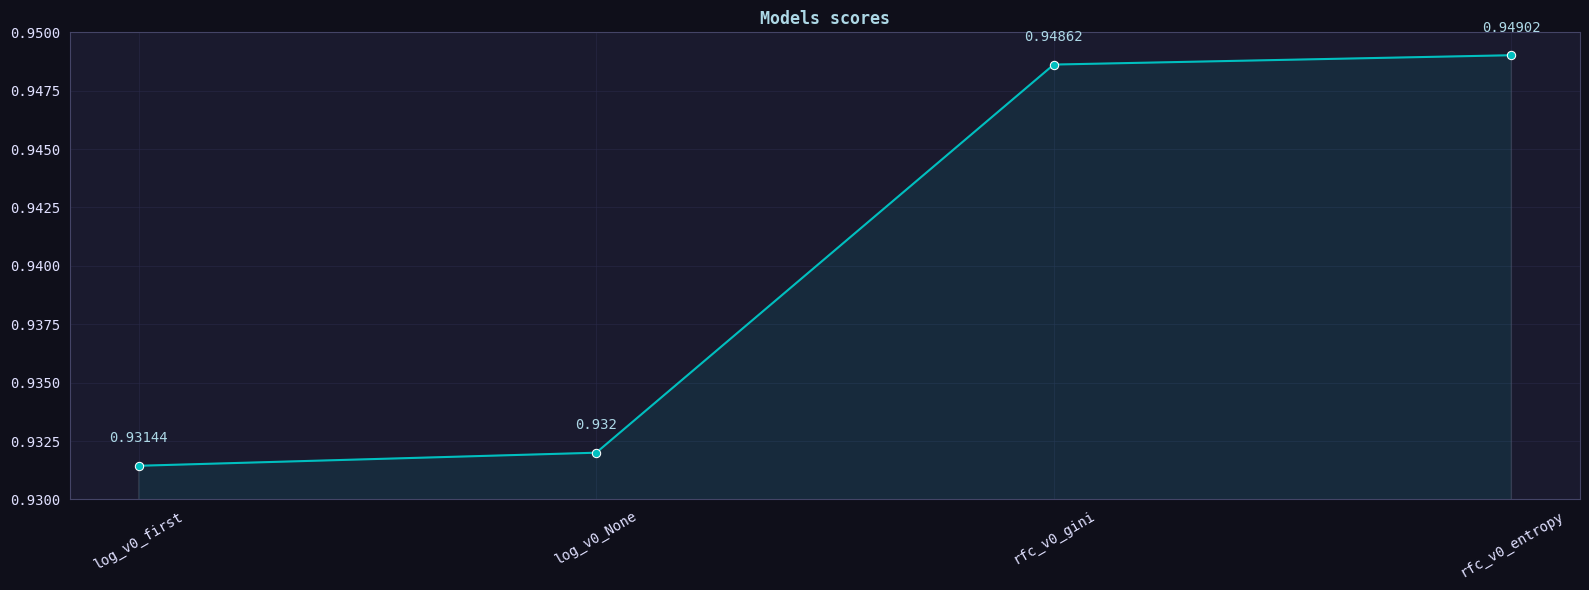

In [37]:
## -- Get Scores --
all_model_scores = {}
all_scores = []

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_model_scores[k] = y
            all_scores.append(float(y))

plt.figure(figsize=(16, 6))
ax = sns.lineplot(all_model_scores, marker='o')

ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
ax.set_title('Models scores', fontweight='semibold')
ax.tick_params('x', rotation=30)
ax.set_ylim(0.93, 0.95)

for i, s in enumerate(all_model_scores.values()):
    ax.text(float(i), s+1e-3, s, ha='center', va='baseline')

plt.tight_layout()
plt.show()
print()

In [38]:
pd.Series(all_model_scores).sort_values()

log_v0_first      0.93144
log_v0_None       0.93200
rfc_v0_gini       0.94862
rfc_v0_entropy    0.94902
dtype: float64

log_v0_first_93144 saved!


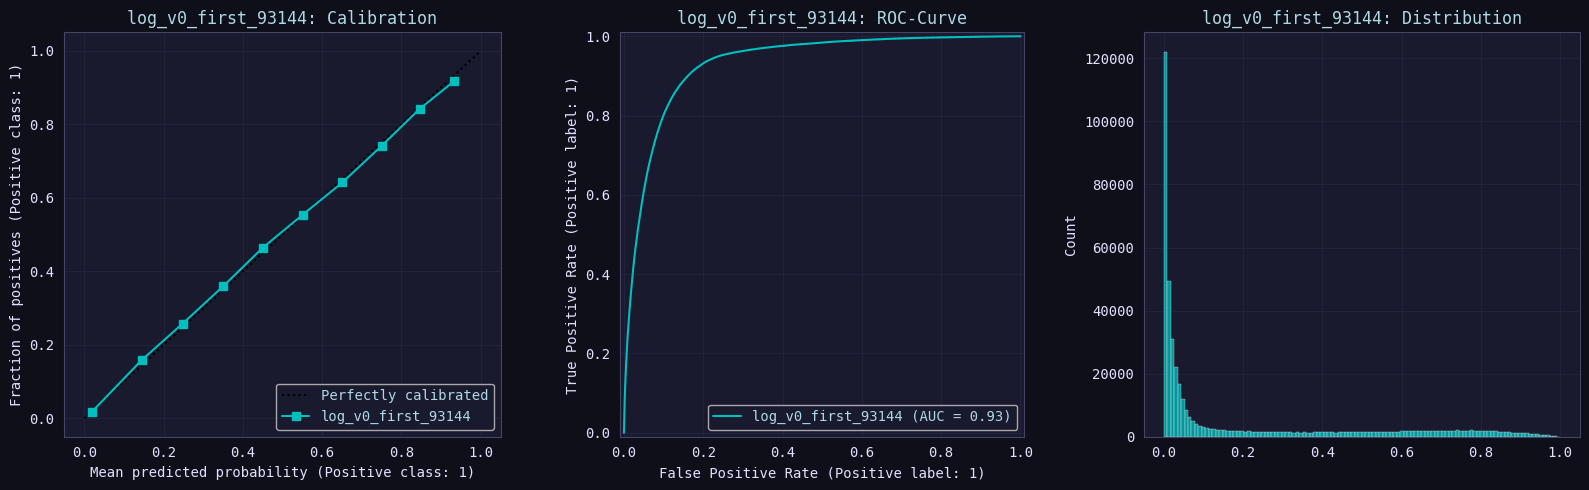


log_v0_None_932 saved!


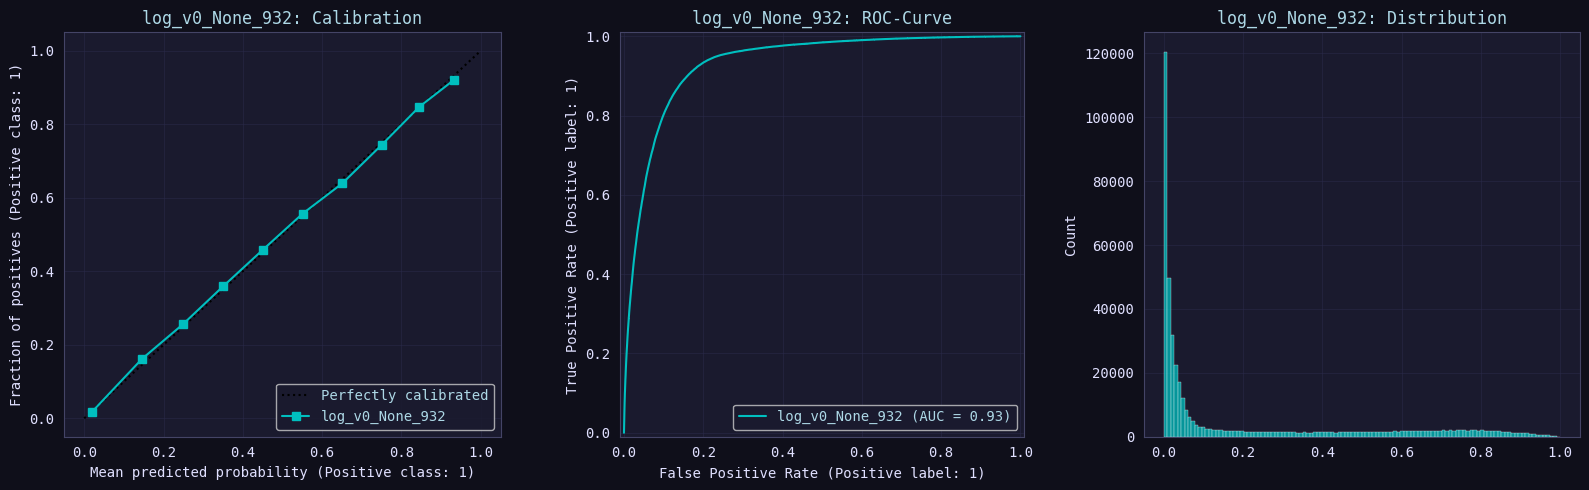


rfc_v0_gini_94862 saved!


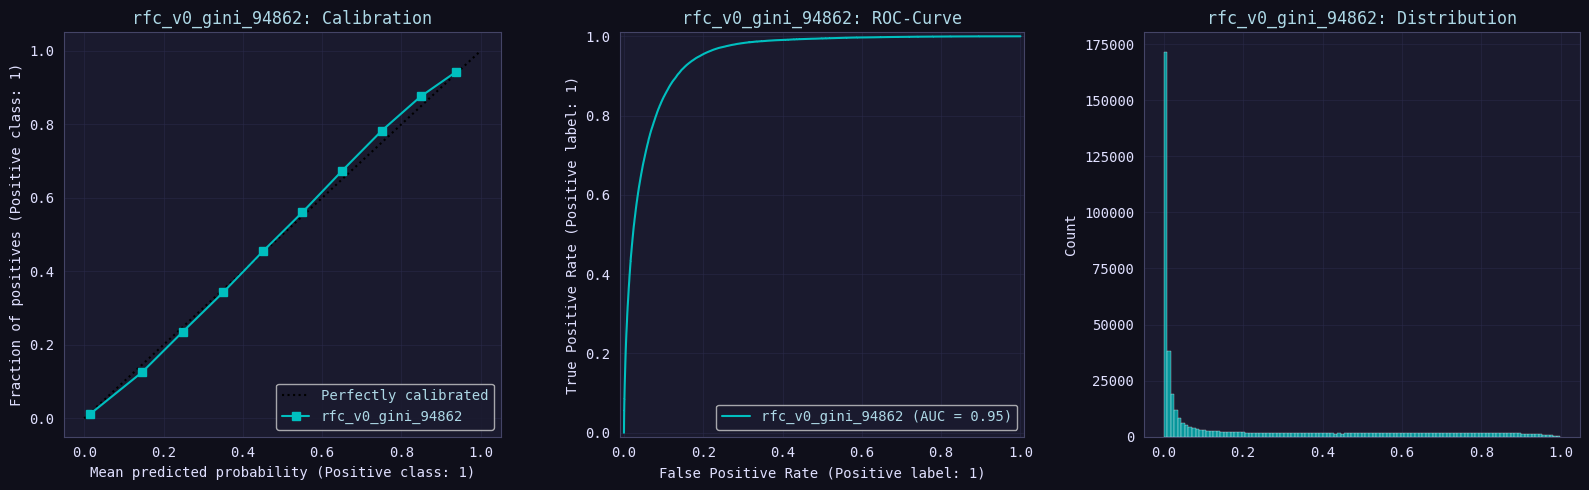


rfc_v0_entropy_94902 saved!


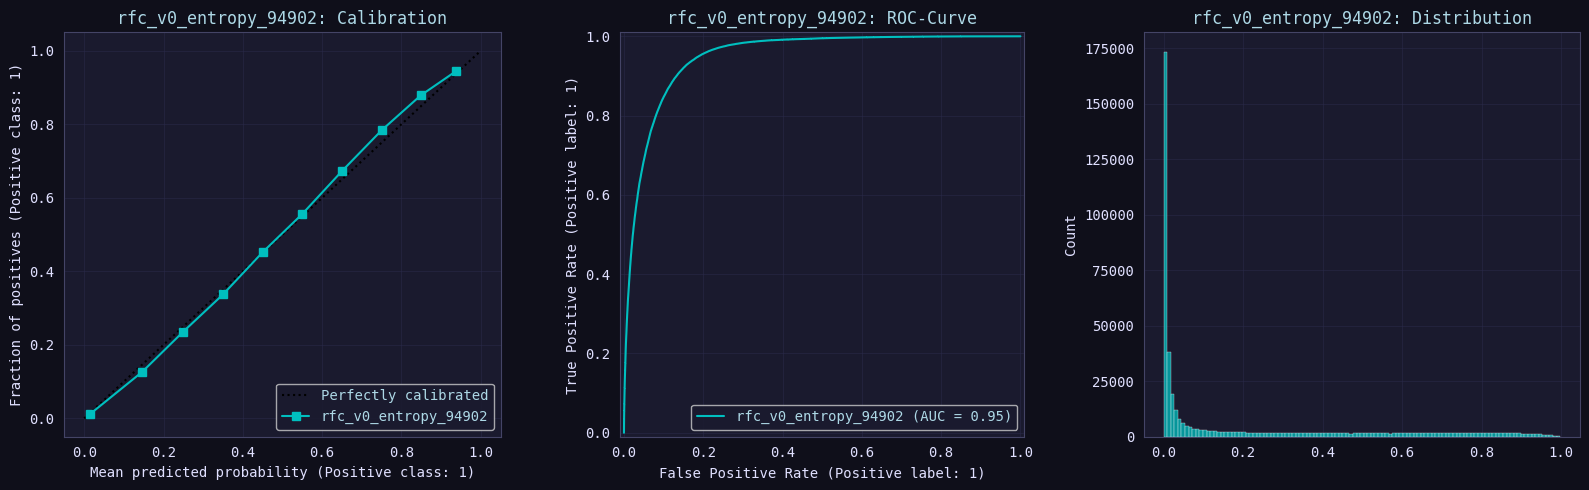

In [39]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_model_predictions.items()):
    for key_, data_ in v.items():
        if key_ == 'oof_preds':
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f'{n} saved!')

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [40]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f'submit_base_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')
            model_results[n] = y

print()
pd.DataFrame(model_results).head(10)

log_v0_first_93144 saved! (188165,)
log_v0_None_932 saved! (188165,)
rfc_v0_gini_94862 saved! (188165,)
rfc_v0_entropy_94902 saved! (188165,)



,log_v0_first_93144,log_v0_None_932,rfc_v0_gini_94862,rfc_v0_entropy_94902
0,0.002805,0.002821,0.003026,0.004990
1,0.003863,0.004451,0.021261,0.019755
2,0.004647,0.003961,0.001339,0.002708
3,0.228619,0.232639,0.243595,0.243137
4,0.659099,0.667407,0.860416,0.859570
5,0.272244,0.289284,0.242750,0.217282
6,0.007493,0.009340,0.000131,0.000203
7,0.044513,0.036461,0.002691,0.000877
8,0.036954,0.035617,0.037391,0.027113
9,0.004921,0.005480,0.004670,0.002019


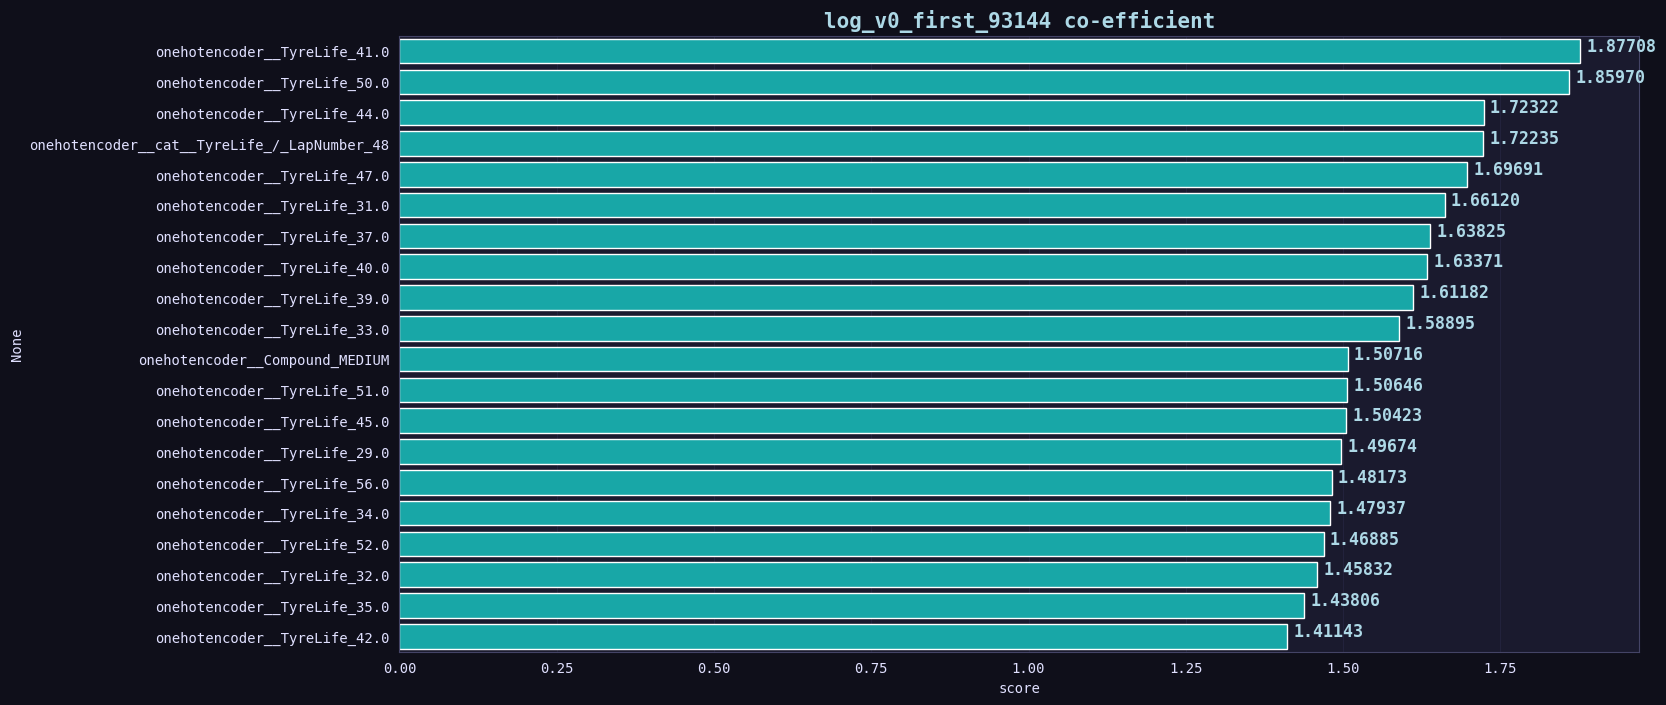

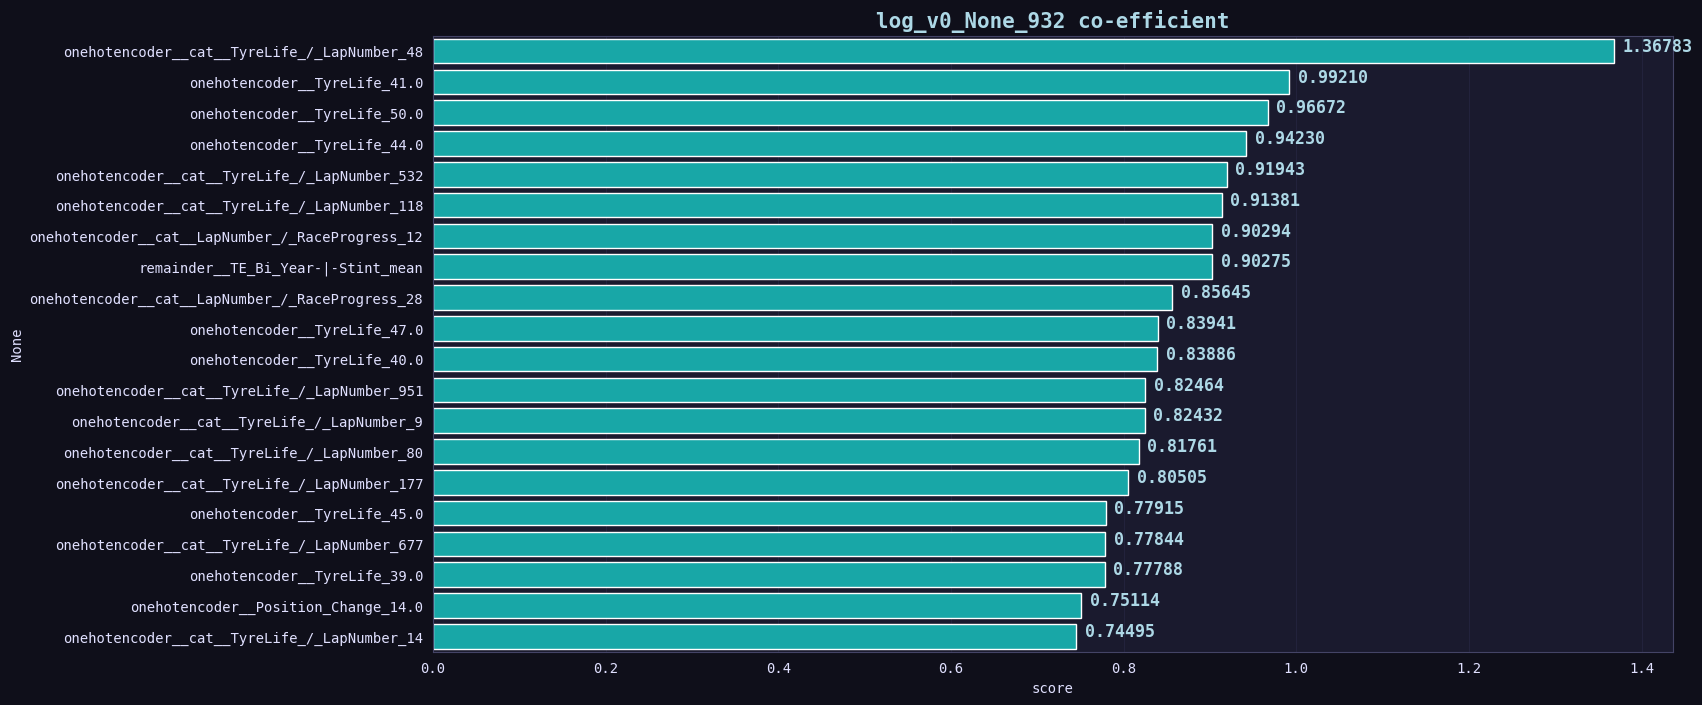

In [41]:
## -- Feature Importances: Linear Model --
log_first = all_model_predictions[list(all_model_predictions.keys())[0]]
log_none  = all_model_predictions[list(all_model_predictions.keys())[1]]

for i, m in enumerate([log_first, log_none]):
    coef_dict = dict(
        zip(
            m['model'][0].get_feature_names_out(),
            m['model'][-1].coef_[0]
        )
    )

    feat_coefs = pd.DataFrame.from_dict(
        coef_dict,
        orient='index',
        columns=['score']
    ).sort_values('score', ascending=False).iloc[:20] # -> Top features
    
    feat_coefs.columns = ['score']

    plt.figure(figsize=(16, 8))
    sns.barplot(data=feat_coefs, x='score', y=feat_coefs.index)
    plt.title(list(model_results.keys())[i] + ' co-efficient',
              fontsize=15, fontweight='semibold')

    for i, t in enumerate(feat_coefs['score'].values):
        plt.text(t+1e-2, i, f'{t:.5f}', fontdict={'size': 12, 'weight': 'bold'})

    # plt.tight_layout()
    plt.show()
    print()

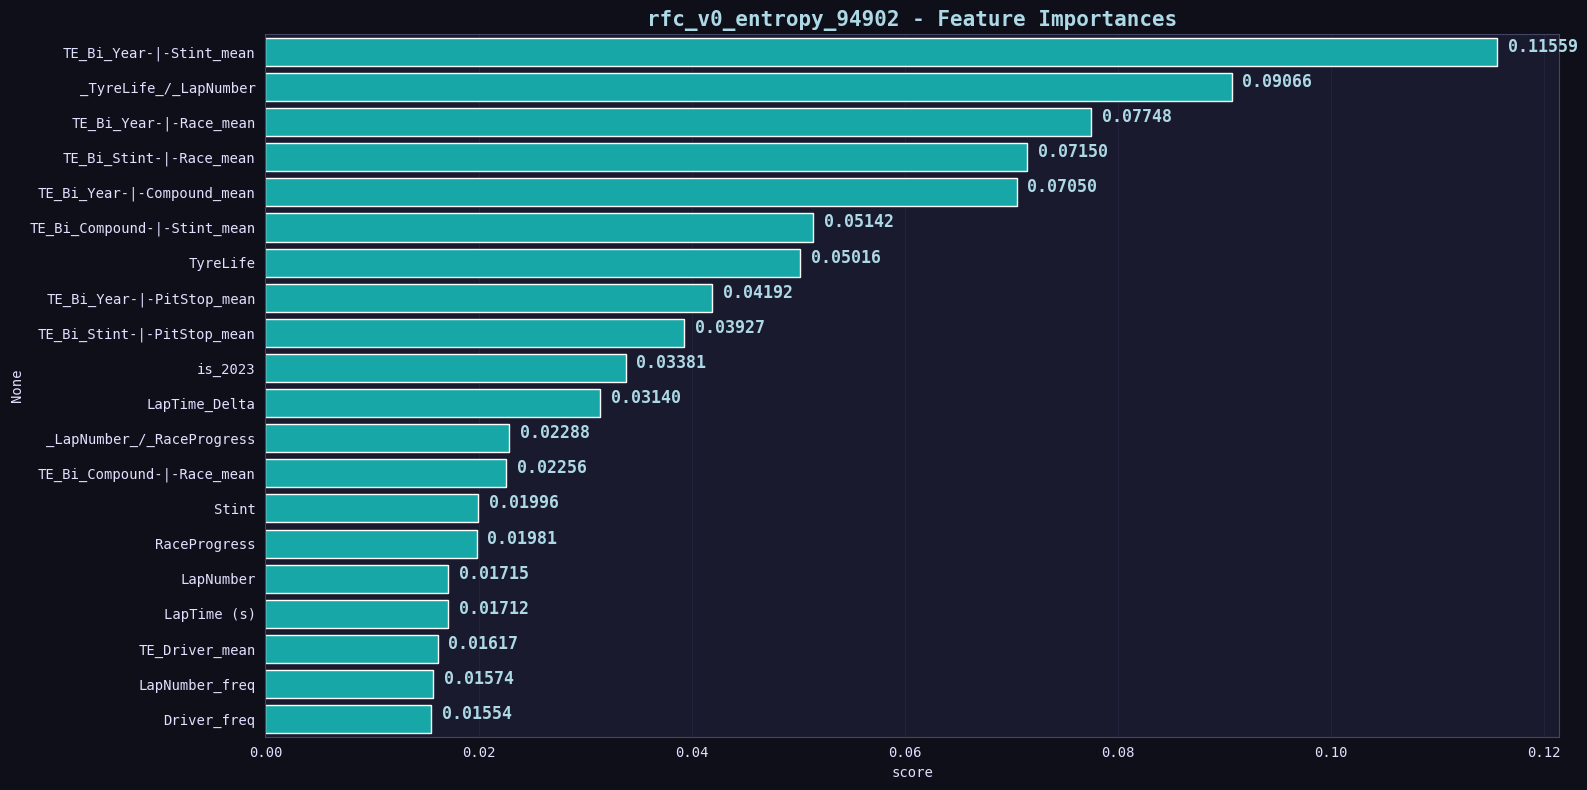

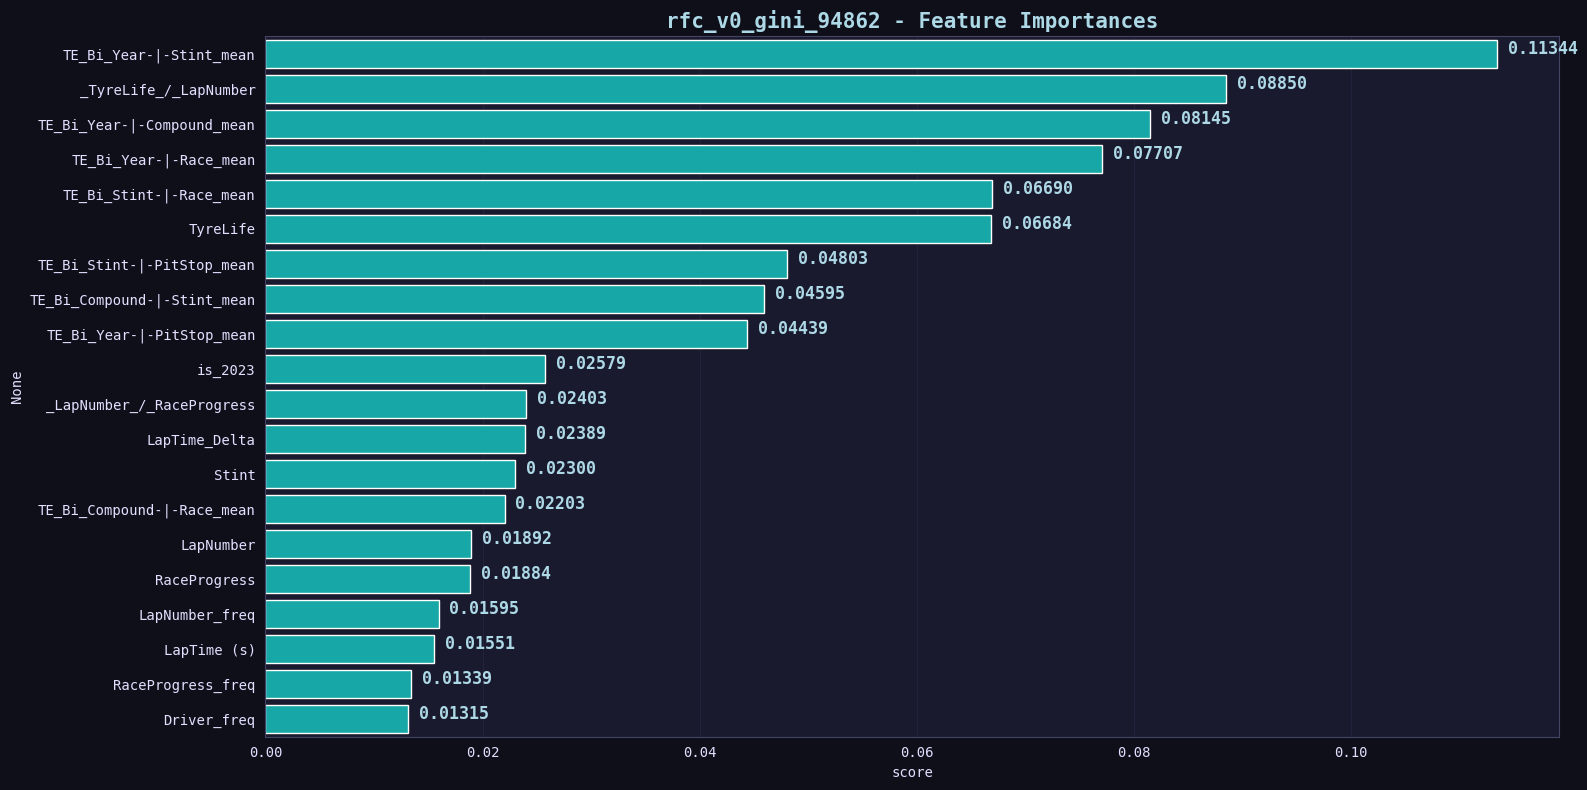

In [42]:
## -- Feature Importances: Linear Model --
rfc_entr = all_model_predictions[list(all_model_predictions.keys())[-1]]
rfc_gini = all_model_predictions[list(all_model_predictions.keys())[-2]]

for i, m in enumerate([rfc_entr, rfc_gini], 1):
    imporatnces = dict(zip(m['val_data'].columns.tolist(), m['model'].feature_importances_))
    feat_imp = pd.DataFrame.from_dict(
        imporatnces,
        orient='index',
        columns=['score']
    ).sort_values('score', ascending=False).iloc[:20] # -> Top features

    feat_imp.columns = ['score']

    plt.figure(figsize=(16, 8))
    sns.barplot(data=feat_imp, x='score', y=feat_imp.index)
    plt.title(f'{list(model_results.keys())[-i]} - Feature Importances',
              fontsize=15, fontweight='semibold')
    
    for i, t in enumerate(feat_imp['score'].values):
        plt.text(t+1e-3, i, f'{t:.5f}', fontdict={'size': 12, 'weight': 'bold'})
    
    plt.tight_layout()
    plt.show()
    print()

In [43]:
# %pip install -q -U shap
import shap

print(f"Shap version: {shap.__version__}")

Shap version: 0.50.0


In [44]:
# max_display = 15

# ## -- Shap Explainer --
# explainer = shap.TreeExplainer(rfc_gini['model'])
# explanation = explainer(rfc_gini['val_data'].iloc[:100])

# ## -- Bar plot --
# plt.subplot(121)
# shap.plots.bar(
#     explanation[0],
#     max_display=max_display,
#     show=False
# )
# plt.title('Bar - Overall impact on model predictions')

# ## -- Beeswarm plot --
# plt.subplot(122)
# shap.plots.beeswarm(
#     explanation,
#     max_display=max_display,
#     order=explanation.abs.max(0),
#     color_bar=False,
#     plot_size=(18, 8),
#     show=False,
# )

# plt.title('Beeswarm - Most impactful features')

# plt.tight_layout(pad=1.5)
# plt.show()
# print()

# HILLCLIMB

In [45]:
oof_df = pd.DataFrame()
pred_df = pd.DataFrame()
print("Loading data: ", end="")
for (root, dirs, files) in os.walk("/kaggle/working"):
    for i, file in enumerate(sorted(files), 1):
        if i%20 == 0: print(f"{i}%.. ", end="")
        if file.endswith(".npy") and "oof" in file:
            oof_df = pd.concat([oof_df, pd.Series(np.load(os.path.join(root, file)), name=file[4:-4])], axis=1)
        elif file.endswith(".npy") and "test" in file:
            pred_df = pd.concat([pred_df, pd.Series(np.load(os.path.join(root, file)), name=file[5:-4])], axis=1)

print(CFG.YELLOW)

print(f"OOF  loaded : {len(oof_df.shape)}")
print(f"TEST loaded : {len(pred_df.shape)}")

display(oof_df.head())
display(pred_df.head())

Loading data: 
OOF  loaded : 2
TEST loaded : 2


,log_v0_None_932,log_v0_first_93144,rfc_v0_entropy_94902,rfc_v0_gini_94862
0,0.802627,0.760452,0.734451,0.757956
1,0.313518,0.316256,0.415294,0.436176
2,0.428164,0.382646,0.520018,0.518117
3,0.000259,0.000302,0.000509,0.000392
4,0.323632,0.309734,0.270362,0.254293


,log_v0_None_932,log_v0_first_93144,rfc_v0_entropy_94902,rfc_v0_gini_94862
0,0.002821,0.002805,0.004990,0.003026
1,0.004451,0.003863,0.019755,0.021261
2,0.003961,0.004647,0.002708,0.001339
3,0.232639,0.228619,0.243137,0.243595
4,0.667407,0.659099,0.859570,0.860416


In [46]:
# pred_df.shape

In [47]:
try:
    from hillclimbers import climb_hill, partial
except:
    !pip install -qq -U hillclimbers
    from hillclimbers import climb_hill, partial

  Preparing metadata (setup.py) ... done


In [48]:
%%time
trn = pd.read_csv(PATH+"train.csv").drop('id', axis=1)
pred_hc, oof_hc = climb_hill(
                               train = trn,
                              target = TARGET,
                         oof_pred_df = oof_df,
                        test_pred_df = pred_df,
                           objective = 'maximize',
                         eval_metric = partial(roc_auc_score),
                    # negative_weights = True,
                    return_oof_preds = True,
                           precision = 0.01,
                           plot_hill = True,
                           plot_hist = True,
    )

   /\  
  /__\  hillclimbers 
 /    \
/______\ 

Models to be ensembled | (4 total): 

rfc_v0_entropy_94902: 0.94902 (best solo model)
rfc_v0_gini_94862:    0.94862
log_v0_None_932:      0.93200
log_v0_first_93144:   0.93144

[Data preparation completed successfully] - [Initiate hill climbing] 

Iteration: 1 | Model added: log_v0_None_932 | Best weight: 0.02 | Best roc_auc_score: 0.94903
Iteration: 2 | Model added: rfc_v0_gini_94862 | Best weight: 0.10 | Best roc_auc_score: 0.94904


CPU times: user 41 s, sys: 1.76 s, total: 42.8 s
Wall time: 43.7 s


In [49]:
# print(f"Hillclimb score: {round(roc_auc_score(train[TARGET], oof_hc), 5)}")
# hc_auc = str(round(roc_auc_score(train[TARGET], oof_hc), 5)).split('.')[1]

In [50]:
# len(oof_hc), len(train[TARGET])

In [51]:
# np.save(f"oof_log-hc_seed{seeding}.npy", oof_hc)
# np.save(f"pred_log-hc_seed{seeding}.npy", pred_hc)

In [52]:
# submit[TARGET] = pred_hc
# submit.to_csv(f"submit_HC-log-seed{seeding}_{hc_auc}.csv", index=False)
# print(f"✅ Saved hillclimb predictions!!!")
# submit.head()

In [53]:
# len(oof_hc), len(pred_hc)